In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from pprint import pformat

from hloc import (
    extract_features,
    match_features,
    match_dense,
    pairs_from_covisibility,
    pairs_from_retrieval,
)
from hloc import colmap_from_nvm, triangulation, localize_sfm, visualization
import numpy as np
import pandas as pd
from pipeline_utils import read_images_text, colmap_dict_to_pose
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Pipeline for UCF 3251 visual localization

In [4]:
dataset = Path("datasets/3251/")  # change this if your dataset is somewhere else
images = dataset / "images"
outputs = Path("outputs/3251")  # where everything will be saved

# list the standard configurations available
print(f"Configs for feature extractors:\n{pformat(extract_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_dense.confs)}")

Configs for feature extractors:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'megaloc': {'model': {'name': 'megaloc'},
             'output': 'global-feats-megaloc',
             'preprocessing': {'resize_max': 1024}},
 'netvlad': {'model': {'name': 'netvlad'},
             'output': 'global-feats-netvlad',
             'preprocessing': {'resize_max': 1024}},
 'openibl': {'model':

In [5]:
# pick one of the configurations for image retrieval, local feature extraction, and matching
retrieval_conf = extract_features.confs["netvlad"]

feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["superpoint+lightglue"]
#matcher_conf = match_dense.confs['loftr']

reference_sfm = outputs / "sparse_model_superpoint_inloc_superpoint+lightglue"  # the SfM model we will build

## Extract local features for database

In [ ]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features = extract_features.main(feature_conf, images, outputs)

The function returns the path of the file in which all the extracted features are stored.

## Generate pairs for the SfM reconstruction
Instead of matching all database images exhaustively, we exploit the existing SIFT model to find which image pairs are the most covisible. We do a covisiblity search, selecting the top 20 most covisibile neighbors for each image.

In [ ]:
sfm_pairs = outputs / "pairs-db-covis20.txt"  # top 20 most covisible in SIFT model
pairs_from_covisibility.main(outputs / "sfm_sift", sfm_pairs, num_matched=20)

## Match the database images

In [ ]:
if matcher_conf["model"]["name"] != "loftr":
    sfm_matches = match_features.main(
        matcher_conf, sfm_pairs, feature_conf["output"], outputs
    )

In [ ]:
# LOFTR
if matcher_conf["model"]["name"] == "loftr":
    features, sfm_matches = match_dense.main(
            matcher_conf, sfm_pairs, images, outputs, max_kps=8192, overwrite=False
        )

## Triangulate a new SfM model from the given poses
We triangulate the sparse 3D pointcloud given the matches and the reference poses stored in the SIFT COLMAP model.

In [ ]:
reconstruction = triangulation.main(
    reference_sfm, outputs / "sfm_sift", images, sfm_pairs, features, sfm_matches
)

## Find image pairs via image retrieval
We extract global descriptors with NetVLAD and find for each image the $k$ most similar ones. A larger $k$ improves the robustness of the localization for difficult queries but makes the matching more expensive. Using $k{=}10{-}20$ is generally a good tradeoff.

In [ ]:
global_descriptors = extract_features.main(retrieval_conf, images, outputs)

# Query Images

In [32]:
num_retrival=20
retrival = "netvlad"
query_set = 0
retrieval_conf = extract_features.confs[retrival]

query_images = dataset / f"query_{query_set}"
outputs_query = outputs / f"query_{query_set}"
loc_pairs = outputs / f"pairs-query_{query_set}-{retrival}{num_retrival}.txt"
global_descriptors = outputs / f"global-feats-{retrival}.h5"
query_descriptors = outputs_query / f"global-feats-{retrival}.h5"


In [ ]:
# Superpoint+SuperGlue
# feature_conf = extract_features.confs["superpoint_inloc"]
# matcher_conf = match_features.confs["superglue"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_superpoint+superglue"
# features = outputs / "feats-superpoint-n4096-r1600.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [33]:
# Superpoint+Lightglue
feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["superpoint+lightglue"]
matcher_name = matcher_conf["output"]

reconstruction = outputs / "sparse_model_superpoint_inloc_superpoint+lightglue"
features = outputs / "feats-superpoint-n4096-r1600.h5"
inlier_threshold = 32

results = outputs / f"3259_hloc_query{query_set}_{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# Superpoint+NN
# feature_conf = extract_features.confs["superpoint_inloc"]
# matcher_conf = match_features.confs["NN-superpoint"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_superpoint+NN"
# features = outputs / "feats-superpoint-n4096-r1600.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_superpoint+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# Sift+NN
# feature_conf = extract_features.confs["sift"]
# matcher_conf = match_features.confs["NN-ratio"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_sift+NN"
# features = outputs / "feats-sift.h5"
# inlier_threshold = 32

# results = outputs / f"3259_hloc_query{query_set}_sift+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
## DISK+LightGlue
# feature_conf = extract_features.confs["disk"]
# matcher_conf = match_features.confs["disk+lightglue"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_disk+lightglue"
# features = outputs / "feats-disk.h5"
# inlier_threshold = 40

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# DISK2+NN
# feature_conf = extract_features.confs["disk2"]
# matcher_conf = match_features.confs["NN-ratio"]
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_disk2+NN"
# features = outputs / "feats-disk2.h5"
# inlier_threshold = 10

# results = outputs / f"3259_hloc_query{query_set}_disk+{matcher_name}_{retrival}{num_retrival}.txt"  # the result file

In [ ]:
# LOFTR
# matcher_conf = match_dense.confs['loftr']
# matcher_name = matcher_conf["output"]

# reconstruction = outputs / "sfm_loftr"
# features = outputs / f"feats_{matcher_name}.h5"
# inlier_threshold = 100

# query_matches = outputs_query / f"matches-loftr_{loc_pairs.stem}.h5"
# results = outputs / f"3259_hloc_loftr_{retrival}{num_retrival}.txt"

## Feature extraction Query

In [34]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    features_query = extract_features.main(feature_conf, query_images, outputs_query)
    print(features_query)

[2026/09/18 09:52:51 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 4},
 'output': 'feats-superpoint-n4096-r1600',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2026/09/18 09:52:51 hloc INFO] Found 90 images in root datasets/3251/query_0.
[2026/09/18 09:52:51 hloc INFO] Skipping the extraction.


outputs/3251/query_0/feats-superpoint-n4096-r1600.h5


In [35]:
query_descriptors = extract_features.main(retrieval_conf, query_images, outputs_query)
print(query_descriptors)

[2026/09/18 09:52:54 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
[2026/09/18 09:52:54 hloc INFO] Found 90 images in root datasets/3251/query_0.
[2026/09/18 09:52:54 hloc INFO] Skipping the extraction.


outputs/3251/query_0/global-feats-netvlad.h5


In [36]:
pairs_from_retrieval.main(
    query_descriptors, loc_pairs, num_matched=num_retrival, db_prefix=None,
    query_prefix=None, db_descriptors=global_descriptors
)

[2026/09/18 09:52:55 hloc INFO] Extracting image pairs from a retrieval database.
[2026/09/18 09:52:56 hloc INFO] Found 1800 pairs.


## Match the query images

In [37]:
def remove_reverse_duplicate_pairs(input_path: Path, output_path: Path):
    seen = set()
    kept = []
    original_count = 0
    removed_count = 0

    with input_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            original_count += 1

            name0, name1 = line.split()
            pair_key = frozenset((name0, name1))

            if pair_key in seen:
                removed_count += 1
                continue

            seen.add(pair_key)
            kept.append((name0, name1))

    with output_path.open("w") as f:
        for name0, name1 in kept:
            f.write(f"{name0} {name1}\n")

    print(f"Original pairs: {original_count}")
    print(f"Unique pairs:   {len(kept)}")
    print(f"Removed pairs:  {removed_count}")

remove_reverse_duplicate_pairs(loc_pairs, loc_pairs)

Original pairs: 1800
Unique pairs:   1799
Removed pairs:  1


In [38]:
# NOT FOR LOFTR
if matcher_conf["model"]["name"] != "loftr":
    query_matches = Path( outputs_query, f'{features_query.stem}_{matcher_conf["output"]}_{loc_pairs.stem}.h5') ## Match OUTPUT location
    loc_matches = match_features.main(
        matcher_conf, loc_pairs, features_query, outputs_query,
        query_matches, features_ref=features
    )

[2026/09/18 09:53:01 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}


[2026/09/18 09:53:02 hloc INFO] Skipping the matching.


In [39]:
# LOFTR
if matcher_conf["model"]["name"] == "loftr":
    features_query, loc_matches = match_dense.main(
            matcher_conf,
            loc_pairs,
            dataset / "combined_with_query",
            outputs_query,
            max_kps=None,
            matches=query_matches,
            features_ref = features
        )

## Localize!

In [40]:
ret, log = localize_sfm.main(
    reconstruction,
    dataset / f"query_list_{query_set}_with_intrinsics.txt",
    loc_pairs,
    features_query,
    loc_matches,
    results,
    covisibility_clustering=False,
    inlier_threshold = inlier_threshold,
)  # not required with SuperPoint+SuperGlue

[2026/09/18 09:53:06 hloc.utils.parsers INFO] Imported 90 images from query_list_0_with_intrinsics.txt


[2026/09/18 09:53:06 hloc INFO] Reading the 3D model...
[2026/09/18 09:53:06 hloc INFO] Starting localization...
 72%|███████▏  | 65/90 [00:04<00:01, 14.30it/s]


IndexError: index 608 is out of bounds for axis 0 with size 607

## Visualizing the SfM model
We visualize some of the database images with their detected keypoints.

Color the keypoints by track length: red keypoints are observed many times, blue keypoints few.

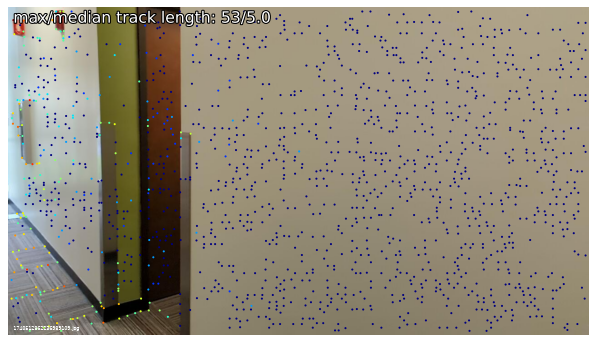

In [41]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="track_length")

Color the keypoints by visibility: blue if sucessfully triangulated, red if never matched.

## Visualizing the localization
We parse the localization logs and for each query image plot matches and inliers with a few database images.

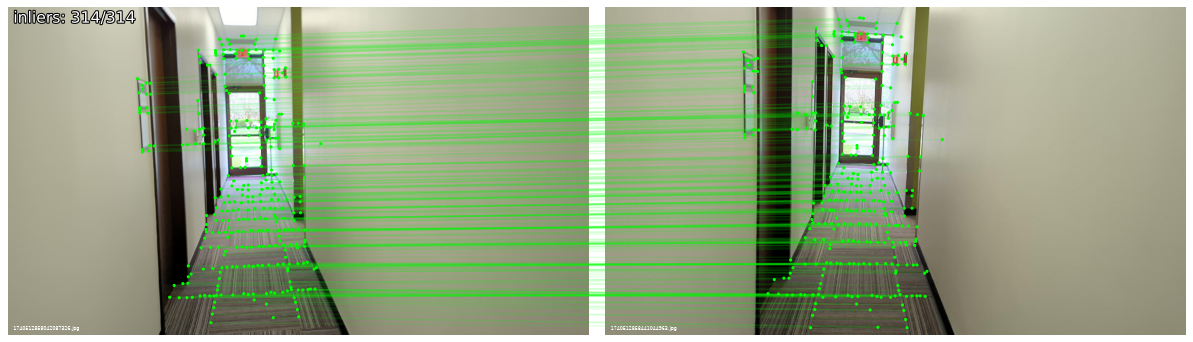

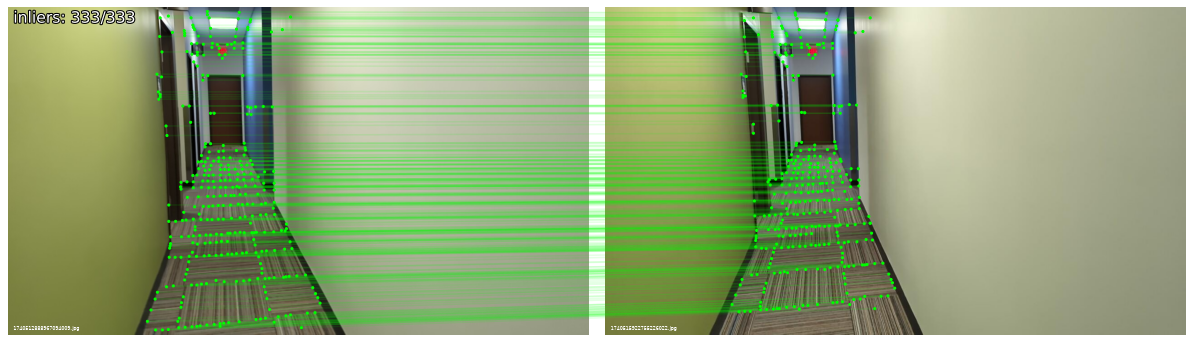

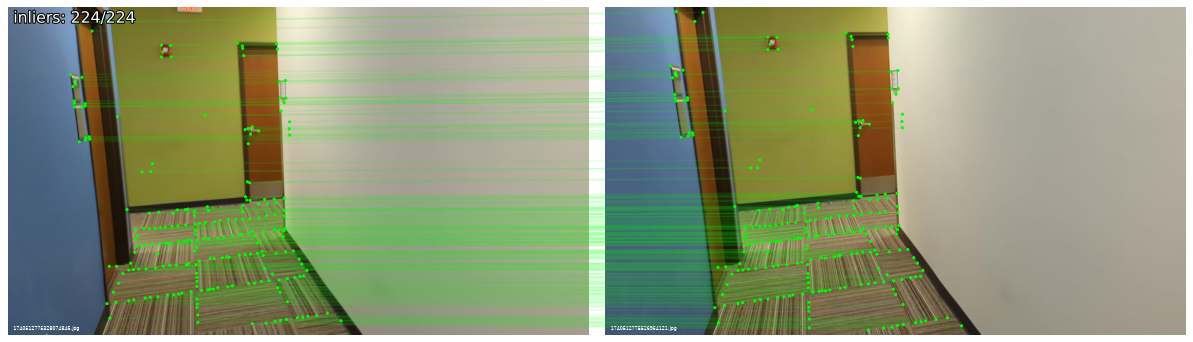

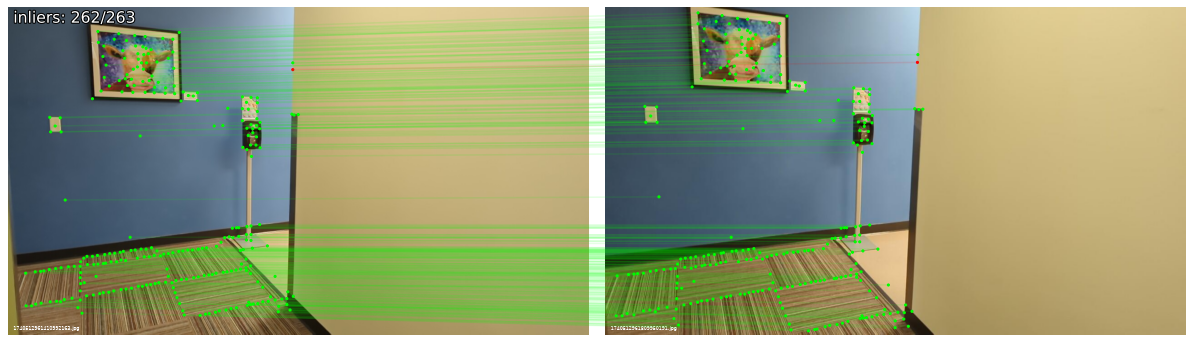

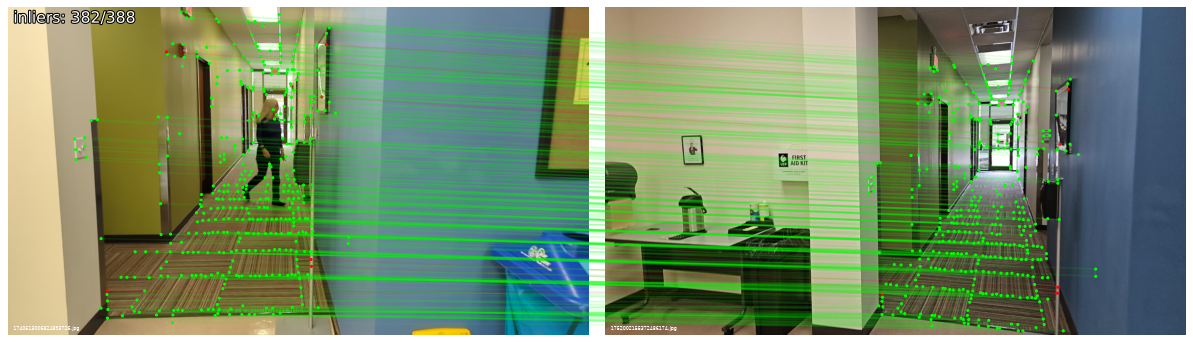

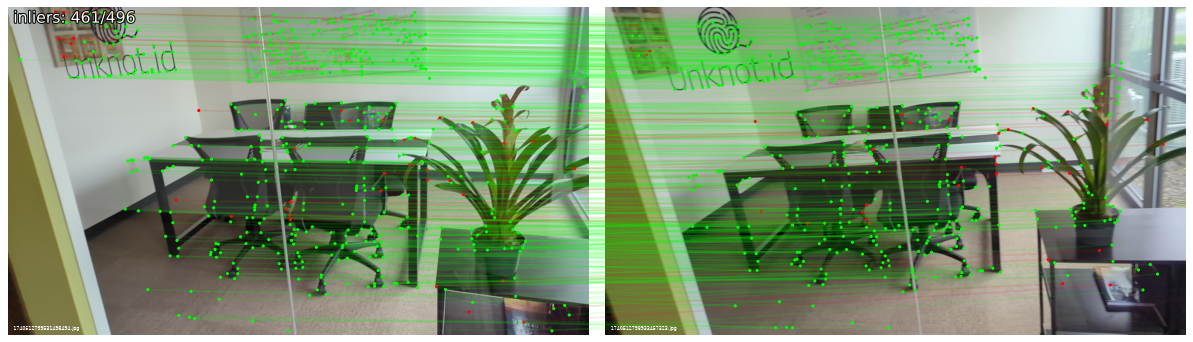

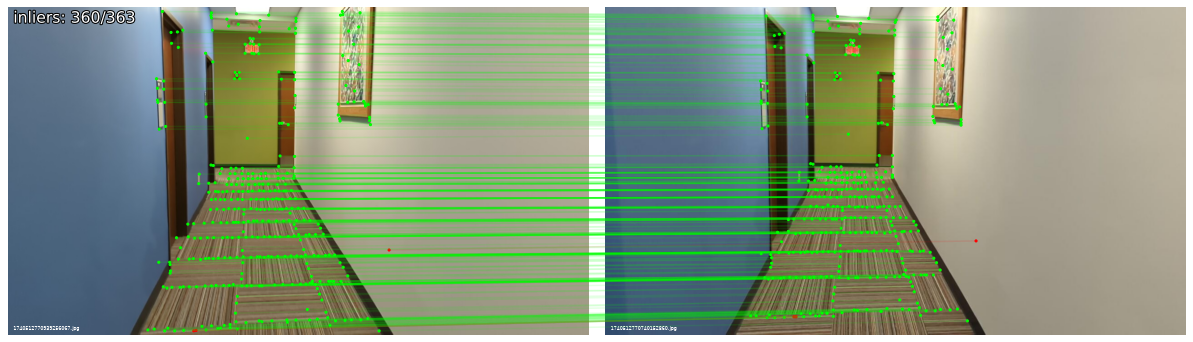

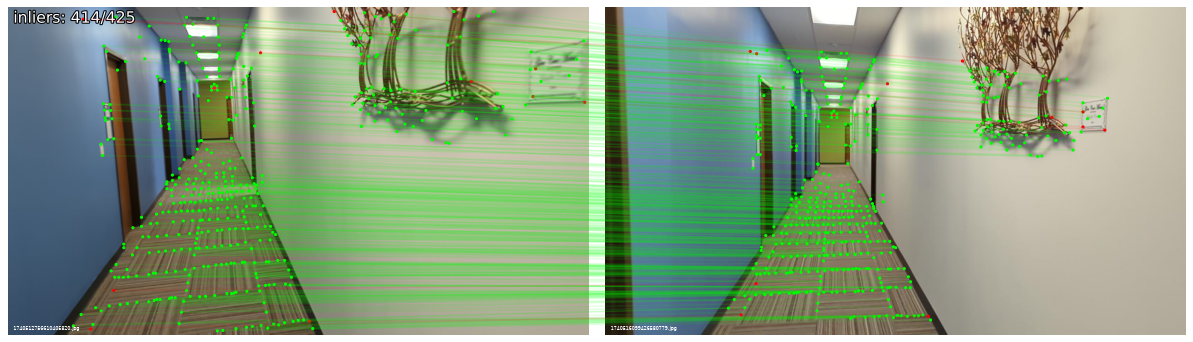

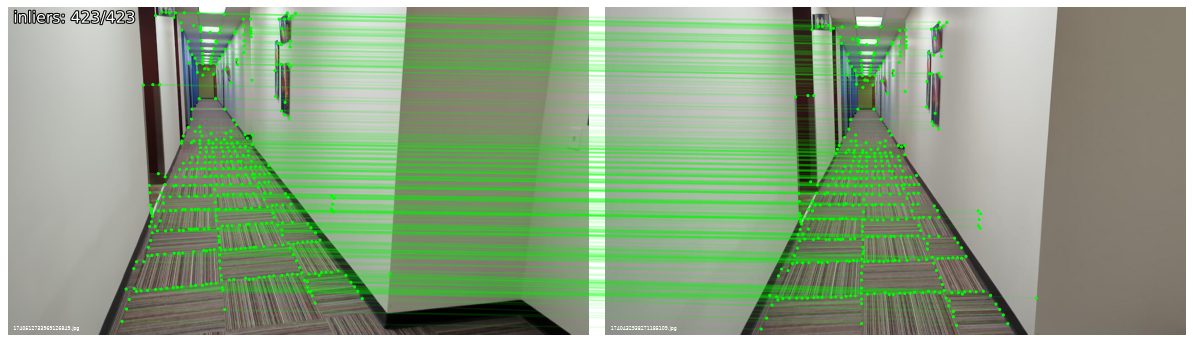

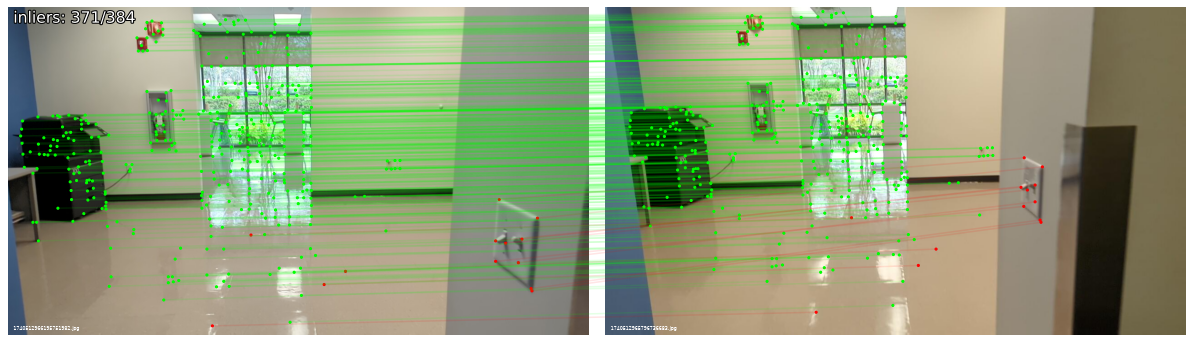

In [42]:
selected = []
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, n=10, top_k_db=1, prefix=None, seed=4
)

In [43]:
out_dict = read_images_text(results)
stamps, xyz, quat = colmap_dict_to_pose(out_dict)
df_pred = pd.DataFrame()
df_pred[["X", "Y", "Z"]] = xyz
df_pred["image_name"] = stamps
# stamps = stamps.reshape(-1, 1)
# final_out = np.hstack((xyz[:, 0:2], stamps))

In [44]:
gt_file = dataset / f"query_list_{query_set}_gt.txt"
df_gt = pd.read_csv(gt_file, sep=' ', header=None, names=['image_name', 'X', 'Y', 'Z'])

plot


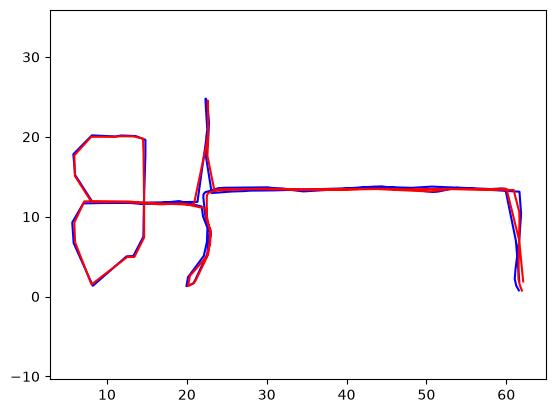

In [46]:
exclude_frames = []
# exclude_frames = ['1734377895414000128.jpg', '1734378021095000064.jpg']
df_plot = df_pred[~df_pred["image_name"].isin(exclude_frames)]
plt.plot(df_plot["X"], df_plot["Y"], color ="blue")
plt.plot(df_gt["X"], df_gt["Y"], color ="red")
plt.axis('equal')
print("plot")

In [47]:
merged_df = pd.merge(df_pred, df_gt, on='image_name', how='inner', suffixes=('_pred', '_gt'))
del_x = merged_df['X_pred'] - merged_df['X_gt']
del_y = merged_df['Y_pred'] - merged_df['Y_gt']
error = del_x**2 + del_y**2
error = np.sqrt(error)

In [48]:
error[error > 5]


Series([], dtype: float64)

In [49]:
merged_df[error > 5]

,X_pred,Y_pred,Z_pred,image_name,X_gt,Y_gt,Z_gt


In [50]:
selected = list(merged_df[error > 5]["image_name"])
print(selected)

[]


In [51]:
error.describe()

count    90.000000
mean      0.312534
std       0.169598
min       0.041945
25%       0.175048
50%       0.283515
75%       0.415807
max       0.750184
dtype: float64

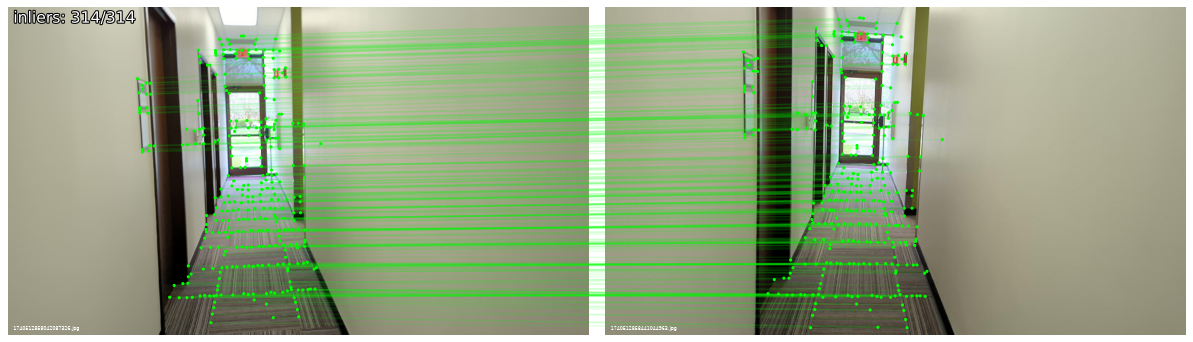

In [52]:
visualization.visualize_loc(
    results, query_images, reconstruction, db_image_dir= images, selected = selected, top_k_db=1, prefix=None, seed=4
)